# Journal de bord

Copier-coller les cellules suivantes comme canevas pour chaque journée.

## 📅 Journal de bord – Jour 1 (10/07/2025)

### 🔧 Étapes / Actions réalisées
- Aquisition, Lecture du brief et préparation de l'environnement
- Setup du repo git pour suivre l'exercice depuis plusieurs poste
- Analyse rapide des données

### 📝 Observations / Difficultés
- Le volume de données me pose probleme pour le travail avec git. Je recherche une solution plus compacte je sais que gzip permet de diminuer de + de 80% les csv donc je vais mettre en place un pipe de compression/decompression

In [1]:
import gzip
with open('dataset/2016_01.csv', 'rb') as f_in, gzip.open('dataset/2016_01.csv.gz', 'wb') as f_out:
    f_out.writelines(f_in)

In [ ]:
import gzip
import os

for m in range(1, 13):
    fname = f'dataset/2016_{m:02d}.csv'
    gzname = f'dataset/2016_{m:02d}.csv.gz'
    if os.path.exists(fname):
        with open(fname, 'rb') as f_in, gzip.open(gzname, 'wb') as f_out:
            f_out.writelines(f_in)
        print(f"Compressé : {fname} -> {gzname}")
    else:
        print(f"Fichier non trouvé : {fname}")

### ✅ Prochaines étapes
- Lire les description des colonnes pour identifier colonnes inutiles ou non éthiques
- Utiliser missingno pour visualiser l'état des données : à première vue il ya beaucoup de données inutiles, des données manquantes, peut etre des doublons
[Projet Git : ](https://github.com/ResidentMario/missingno)
- Trouver le bon moyen pour agréger (ou non ) les 12 fichiers de données


## 📅 Journal de bord – Jour 2 (12/07/2025)

### 🔧 Étapes / Actions réalisées
- Setup projet sur ordinateur de travail
- Installation et tests de visualisation missingno : ça confirme un travail potentiel de nettoyage
- Création d'une fonction pour détecter les erreurs dans les csv

- Je me penche sur la description des colonnes des donnéee (à partir du fichier 01 pour le moment.)
- J'utilise csv2table dans vscode pour une analyse visuelle des données pour le moment
- les données d'aeroport sont redondentes : etat name ... etc. Il y a moyen de réduire le nombre de colonne qui plus est ça prends du poids (ou il faudrait un modèle relationnel)
- Je tente de monter les donnnées brutes dans sqllite pour faire des analyses. et voir si ça me permet de contenir toutes les données dans moins de 100 mo (contrainte git)
- Je décris toutes les colonnes dans un fichier json à partir de la base du Bureau of Transportation Statistics (BTS) des États-Unis (dataset_description.json) . Il me servira à filtrer et typer les données pas la suite
- On a bien 68 colonnes décrites. Je continue l'analyse des colonnes pour voir celles qui sont inutiles ou non éthiques

In [ ]:
import pandas as pd
import sqlite3
import glob

# Connexion à la base SQLite (créée si elle n'existe pas)
conn = sqlite3.connect('flights.db')

# Liste tous les fichiers .csv.gz du dossier dataset/
files = glob.glob('dataset/*.csv.gz')

# for m in range(1, 13):
for file in files:
    print(f"Traitement de {file}")
    # file = f'dataset/2016_{m:02d}.csv.gz'
    # Lecture du fichier gzip (pandas gère nativement)
    df = pd.read_csv(file, dtype=str, compression='gzip', on_bad_lines='skip')  # Ignore les lignes corrompues
   
    
    # Conversion des colonnes numériques (optionnel, à affiner selon le schéma)
    # for col in ['DAY_OF_WEEK', 'AIRLINE_ID', 'FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID']:
    #     if col in df.columns:
    #         df[col] = pd.to_numeric(df[col], errors='coerce')
    # Conversion des booléens
    # for col in ['CANCELLED', 'DIVERTED', 'DEP_DEL15', 'ARR_DEL15']:
    #     if col in df.columns:
    #         df[col] = df[col].astype('float').astype('Int64')
    # Conversion des dates
    # if 'FL_DATE' in df.columns:
    #     df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
    # Insertion dans la base (création de la table si besoin)
    df.to_sql('flights_raw', conn, if_exists='append', index=False)

conn.close()
print("Import terminé.")

### 📝 Observations / Difficultés
- *SQLITE* n'est pas super adapté, je vais utiliser des fichier parquet pour faire le nettoyage et l'analyse des données

Création d'une fonction pour convertir les gzip en parquet pour voir si ça permet d'enviseager une meilleur utilisation des données dans le notebook
Mais Pb le fichier 4 contient des incohérences

In [ ]:
import pandas as pd
import json
import glob
import os

def csv_gz_to_parquet(json_path, csv_dir, output_dir):
    # Charge la description des colonnes
    with open(json_path, 'r', encoding='utf-8') as f:
        desc = json.load(f)

    # Liste des colonnes à garder et mapping type
    keep_cols = []
    type_map = {}
    for cat in desc.values():
        for col in cat:
            if col["keep"]:
                keep_cols.append(col["name"])
                type_map[col["name"]] = col["type"]

    # Crée le dossier de sortie si besoin
    os.makedirs(output_dir, exist_ok=True)

    # Parcourt les fichiers csv.gz
    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"Traitement de {file}")
        df = pd.read_csv(file, compression='gzip', dtype=str, low_memory=False)
        # Filtre les colonnes
        df = df[[col for col in keep_cols if col in df.columns]]
        # Conversion des types
        for col, typ in type_map.items():
            if col in df.columns:
                if typ == "int":
                    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
                elif typ == "float":
                    df[col] = pd.to_numeric(df[col], errors='coerce')
                elif typ == "bool":
                    df[col] = df[col].astype('float').astype('Int64').astype('boolean')
                elif typ == "date":
                    df[col] = pd.to_datetime(df[col], errors='coerce')
                # str : rien à faire
        # Enregistre en parquet
        base = os.path.splitext(os.path.basename(file))[0]
        out_path = os.path.join(output_dir, f"{base}.parquet")
        df.to_parquet(out_path, index=False)
        print(f"Fichier sauvegardé : {out_path}")

# Exemple d'appel :
csv_gz_to_parquet(
    json_path="data/dataset_description.json",
    csv_dir="dataset",
    output_dir="parquet"
)

### Convertion du dataset en fichiers .parquet et avec filtrages des colonnes utiles
- J'utilise la fonction csv_gz_to_parquet_v2 pour convertir l'ensemble des fichiers gzip en parquet. Cette fonction lit le fichier JSON de description des colonnes, filtre les colonnes inutiles, et convertit les types de données selon la description.
- Cela rempli les données ambigu avec des valeurs par défaut (par exemple, 0 pour les entiers, NaN pour les flottants, etc.)
- J'ai choisi de ne pas me pencher plus en profondeur sur les 11 lignes du pack 4 qui ne sont pas interprétable sans les reconstruire. Je les ignore mais j'ai loggué un fichier csv pour les retrouver si besoin.

In [ ]:
import pandas as pd
import json
import glob
import os
import csv
import gzip

def csv_gz_to_parquet_v2(json_path, csv_dir, output_dir):

    # Charge la description des colonnes
    with open(json_path, 'r', encoding='utf-8') as f:
        desc = json.load(f)

    keep_cols = []
    type_map = {}
    for cat in desc.values():
        for col in cat:
            if col["keep"]:
                keep_cols.append(col["name"])
                type_map[col["name"]] = col["type"]

    os.makedirs(output_dir, exist_ok=True)

    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"🔄 Traitement de {file}")
        try:
            valid_rows = []
            invalid_rows = []

            with gzip.open(file, 'rt', encoding='utf-8', errors='replace') as f_in:
                reader = csv.reader(f_in, delimiter=',', quotechar='"')
                header = next(reader)  # utilise le header réel du fichier
                expected_col_count = len(header)

                for i, row in enumerate(reader, start=2):  # start=2 car header = ligne 1
                    if len(row) == expected_col_count:
                        valid_rows.append(row)
                    else:
                        invalid_rows.append({
                            "line_number": i,
                            "columns": len(row),
                            "row": row
                        })

            df = pd.DataFrame(valid_rows, columns=header)

            # Sélectionne uniquement les colonnes nécessaires
            df = df[[col for col in keep_cols if col in df.columns]]

            for col, typ in type_map.items():
                if col in df.columns:
                    if typ == "int":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce').astype('Int64')
                    elif typ == "float":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce')
                    elif typ == "bool":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce') \
                                    .astype('Int64').astype('boolean')
                    elif typ == "date":
                        df[col] = pd.to_datetime(df[col].replace('', pd.NaT), errors='coerce')

            base = os.path.splitext(os.path.basename(file))[0]
            out_path = os.path.join(output_dir, f"{base}.parquet")
            df.to_parquet(out_path, index=False)
            print(f"✅ Parquet sauvegardé : {out_path}")

            if invalid_rows:
                log_path = os.path.join(output_dir, f"{base}_ignored_lines.csv")
                with open(log_path, 'w', newline='', encoding='utf-8') as log_file:
                    writer = csv.writer(log_file)
                    writer.writerow(["line_number", "columns", "row"])
                    for entry in invalid_rows:
                        writer.writerow([entry["line_number"], entry["columns"], json.dumps(entry["row"])])
                print(f"⚠️ Lignes ignorées sauvegardées dans : {log_path} ({len(invalid_rows)} lignes)")

        except Exception as e:
            print(f"❌ Erreur lors du traitement de {file} : {e}")
            
# Exemple d'appel :
csv_gz_to_parquet_v2(
    json_path="data/dataset_description.json",
    csv_dir="./data/raw",
    output_dir="./data/processed"
)

🔄 Traitement de dataset\2016_01.csv.gz
✅ Parquet sauvegardé : parquet\2016_01.csv.parquet
🔄 Traitement de dataset\2016_02.csv.gz
✅ Parquet sauvegardé : parquet\2016_02.csv.parquet
🔄 Traitement de dataset\2016_03.csv.gz
✅ Parquet sauvegardé : parquet\2016_03.csv.parquet
🔄 Traitement de dataset\2016_04.csv.gz
✅ Parquet sauvegardé : parquet\2016_04.csv.parquet
⚠️ Lignes ignorées sauvegardées dans : parquet\2016_04.csv_ignored_lines.csv (11 lignes)
🔄 Traitement de dataset\2016_05.csv.gz
✅ Parquet sauvegardé : parquet\2016_05.csv.parquet
🔄 Traitement de dataset\2016_06.csv.gz
✅ Parquet sauvegardé : parquet\2016_06.csv.parquet
🔄 Traitement de dataset\2016_07.csv.gz
✅ Parquet sauvegardé : parquet\2016_07.csv.parquet
🔄 Traitement de dataset\2016_08.csv.gz
✅ Parquet sauvegardé : parquet\2016_08.csv.parquet
🔄 Traitement de dataset\2016_09.csv.gz
✅ Parquet sauvegardé : parquet\2016_09.csv.parquet
🔄 Traitement de dataset\2016_10.csv.gz
✅ Parquet sauvegardé : parquet\2016_10.csv.parquet
🔄 Traitemen

### Création d'une fonction pour détecter les erreurs dans les csv

In [ ]:

import csv
import gzip

def analyser_structure_csv(file_path, expected_columns=65, max_samples=10):
    nb_total = 0
    nb_invalid = 0
    exemples_invalides = []

    with gzip.open(file_path, 'rt', encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=',', quotechar='"')
        for i, row in enumerate(reader, start=1):
            nb_total += 1
            if len(row) != expected_columns:
                nb_invalid += 1
                if len(exemples_invalides) < max_samples:
                    exemples_invalides.append({
                        "ligne": i,
                        "nb_colonnes": len(row),
                        "contenu": row
                    })

    pourcentage = round((nb_invalid / nb_total) * 100, 4)
    print("📊 Résumé d’analyse du fichier CSV :")
    print(f" - Lignes totales      : {nb_total}")
    print(f" - Lignes invalides    : {nb_invalid}")
    print(f" - Pourcentage invalide: {pourcentage} %")
    print()
    print("🧪 Exemples de lignes invalides :")
    for exemple in exemples_invalides:
        print(f" - Ligne {exemple['ligne']} ({exemple['nb_colonnes']} colonnes)")
        print(f"   ↪ {exemple['contenu'][:5]} ...\n")

    return {
        "nb_total": nb_total,
        "nb_invalides": nb_invalid,
        "pourcentage": pourcentage,
        "exemples": exemples_invalides
    }

# Utilisation :
fichier = "./data/raw/2016_04.csv.gz"
rapport = analyser_structure_csv(fichier)


📊 Résumé d’analyse du fichier CSV :
 - Lignes totales      : 479957
 - Lignes invalides    : 11
 - Pourcentage invalide: 0.0023 %

🧪 Exemples de lignes invalides :
 - Ligne 88688 (42 colonnes)
   ↪ ['2016', '2', '4', '7', '4'] ...

 - Ligne 121012 (75 colonnes)
   ↪ ['2016', '1', '3', '25', '5'] ...

 - Ligne 385888 (49 colonnes)
   ↪ ['2016', '2', '4', '22', '5'] ...

 - Ligne 386249 (83 colonnes)
   ↪ ['2016', '1', '3', '11', '5'] ...

 - Ligne 388291 (78 colonnes)
   ↪ ['2016', '2', '4', '4', '1'] ...

 - Ligne 389371 (72 colonnes)
   ↪ ['2016', '1', '3', '15', '2'] ...

 - Ligne 389548 (81 colonnes)
   ↪ ['2016', '2', '4', '4', '1'] ...

 - Ligne 453858 (97 colonnes)
   ↪ ['2016', '1', '3', '4', '5'] ...

 - Ligne 454123 (40 colonnes)
   ↪ ['2016', '2', '4', '29', '5'] ...

 - Ligne 455029 (58 colonnes)
   ↪ ['2016', '1', '3', '28', '1'] ...



### 📝 Observations / Difficultés
- Lors de la boucle d'injection des données, je m'apercois que certains fichiers ont une structure différentes. par exemple le fichier 04 contient 75 colonnes au lieu de 65 pour les autres
- ex ligne 121011 du pack 4 : ..."Colorado",82,12266,1226603,31453,"IAH",","Santa Ana, CA","CA","06"... il y a un découpage incorect des colonnes
- Choix de UNIQUE_CARRIER comme colonne de référence pour les compagnies aériennes. Il est stable dans le temps et permet de suivre les changements de code IATA

### ✅ Prochaines étapes
- Assembler les données dans un format agrégé afin de passer au nettoyage et analyse

## 📅 Journal de bord – Jour 4 (14/07/2025)

### 🔧 Étapes / Actions réalisées
- Assemblage des fichiers parquets


Charge tous les fichiers .parquet du dossier,
Les concatène en un seul DataFrame,
Sauvegarde le résultat dans ./dataset/all.parquet.

In [17]:
import pandas as pd
import glob
import os

def combine_parquet_files(parquet_dir, output_file):
    files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
    print(f"Fichiers trouvés : {len(files)}")
    dfs = []
    for file in files:
        print(f"Lecture de {file}")
        dfs.append(pd.read_parquet(file))
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Nombre total de lignes : {len(df_all)}")
    df_all.to_parquet(output_file, index=False)
    print(f"✅ Fichier combiné sauvegardé : {output_file}")

# Utilisation :
combine_parquet_files(
    parquet_dir="./parquet",
    output_file="./all.parquet"
)

Fichiers trouvés : 12
Lecture de ./parquet\2016_01.csv.parquet
Lecture de ./parquet\2016_02.csv.parquet
Lecture de ./parquet\2016_03.csv.parquet
Lecture de ./parquet\2016_04.csv.parquet
Lecture de ./parquet\2016_05.csv.parquet
Lecture de ./parquet\2016_06.csv.parquet
Lecture de ./parquet\2016_07.csv.parquet
Lecture de ./parquet\2016_08.csv.parquet
Lecture de ./parquet\2016_09.csv.parquet
Lecture de ./parquet\2016_10.csv.parquet
Lecture de ./parquet\2016_11.csv.parquet
Lecture de ./parquet\2016_12.csv.parquet
Nombre total de lignes : 5635973
✅ Fichier combiné sauvegardé : ./all.parquet


=> 5 635 973 entrées, 68 colonnes réduire à 43 colonnes qui semblent utiles
=> 11 lignes corrompus dans le pack 4, ignorées

### 📝 Observations / Difficultés
- On a un processus de nettoyage à variable pour commmencer le nettoyage exploration des données

### ✅ Prochaines étapes
- 

## 📅 Journal de bord – Jour 5 (21/07/2025)

### 🔧 Étapes / Actions réalisées
- Stratégie de nettoyage des données :
- Suppression des doublon
- Remplacement des valeurs manquantes par des valeurs par défaut
- Conversion des types de données selon la description

### 📝 Observations / Difficultés
- On a un paquet de doublon + de 2% et de colonnes à traiter pour les utiliser

### Generation des .parquet (Equivalents des données brutes) qui sont légèrement plus léger que les gzip et plus facile à manipuler dans pandas

In [ ]:
import pandas as pd
import glob
import os
import csv
import gzip

# Conversion brute des fichiers .csv.gz en .parquet (toutes colonnes), log des lignes invalides

def convert_csv_gz_to_parquet_full_with_log(csv_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"Traitement de {file}")
        valid_rows = []
        invalid_rows = []
        with gzip.open(file, 'rt', encoding='utf-8', errors='replace') as f_in:
            reader = csv.reader(f_in, delimiter=',', quotechar='"')
            header = next(reader)
            expected_col_count = len(header)
            for i, row in enumerate(reader, start=2):
                if len(row) == expected_col_count:
                    valid_rows.append(row)
                else:
                    invalid_rows.append({
                        "line_number": i,
                        "columns": len(row),
                        "row": row
                    })
        df = pd.DataFrame(valid_rows, columns=header)
        base = os.path.splitext(os.path.basename(file))[0]
        out_path = os.path.join(output_dir, f"{base}.parquet")
        df.to_parquet(out_path, index=False)
        print(f"✅ Parquet sauvegardé : {out_path}")
        if invalid_rows:
            log_path = os.path.join(output_dir, f"{base}_ignored_lines.csv")
            with open(log_path, 'w', newline='', encoding='utf-8') as log_file:
                writer = csv.writer(log_file)
                writer.writerow(["line_number", "columns", "row"])
                for entry in invalid_rows:
                    writer.writerow([entry["line_number"], entry["columns"], str(entry["row"])])
            print(f"⚠️ Lignes ignorées sauvegardées dans : {log_path} ({len(invalid_rows)} lignes)")

# Utilisation :
convert_csv_gz_to_parquet_full_with_log(
    csv_dir="data/raw",
    output_dir="data/processed"
)


### Création du fichier combiné pour appliquer des nettoyages

In [9]:
import pandas as pd
import glob
import os

# 2. Concaténation des fichiers .parquet en un seul all_full.parquet et chargement du DataFrame
def combine_parquet_full_files(parquet_dir, output_file):
    files = glob.glob(os.path.join(parquet_dir, "*.csv.parquet"))
    print(f"Fichiers trouvés : {len(files)}")
    dfs = []
    for file in files:
        print(f"Lecture de {file}")
        dfs.append(pd.read_parquet(file))
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Nombre total de lignes : {len(df_all)}")
    df_all.to_parquet(output_file, index=False)
    print(f"✅ Fichier combiné sauvegardé : {output_file}")
    return df_all

# Utilisation :
df_all_full = combine_parquet_full_files(
    parquet_dir="data/processed",
    output_file="data/processed/all_full.parquet"
)

Fichiers trouvés : 12
Lecture de data/processed\2016_01.csv.parquet
Lecture de data/processed\2016_02.csv.parquet
Lecture de data/processed\2016_03.csv.parquet
Lecture de data/processed\2016_04.csv.parquet
Lecture de data/processed\2016_05.csv.parquet
Lecture de data/processed\2016_06.csv.parquet
Lecture de data/processed\2016_07.csv.parquet
Lecture de data/processed\2016_08.csv.parquet
Lecture de data/processed\2016_09.csv.parquet
Lecture de data/processed\2016_10.csv.parquet
Lecture de data/processed\2016_11.csv.parquet
Lecture de data/processed\2016_12.csv.parquet
Nombre total de lignes : 5635973
✅ Fichier combiné sauvegardé : data/processed/all_full.parquet


In [ ]:
import pandas as pd

# 3. Analyse des doublons sur le DataFrame agrégé
# (Suppose que df_all_full est déjà chargé)
nb_total = len(df_all_full)
nb_duplicates = df_all_full.duplicated().sum()
print(f"Nombre total de lignes : {nb_total}")
print(f"Nombre de doublons : {nb_duplicates}")
print(f"Pourcentage de doublons : {nb_duplicates / nb_total * 100:.2f} %")

# Afficher quelques exemples de doublons
if nb_duplicates > 0:
    print("Exemples de doublons :")
    print(df_all_full[df_all_full.duplicated()].head())


Nombre total de lignes : 5635973
Nombre de doublons : 117117
Pourcentage de doublons : 2.08 %
Exemples de doublons :
         YEAR QUARTER MONTH DAY_OF_MONTH DAY_OF_WEEK     FL_DATE  \
1437524  2016       1     3           26           6  2016-03-26   
1437525  2016       1     3           26           6  2016-03-26   
1437526  2016       1     3           26           6  2016-03-26   
1437527  2016       1     3           26           6  2016-03-26   
1437528  2016       1     3           26           6  2016-03-26   

        UNIQUE_CARRIER AIRLINE_ID CARRIER TAIL_NUM  ... DISTANCE_GROUP  \
1437524             AS      19930      AS   N323AS  ...              5   
1437525             AS      19930      AS   N579AS  ...              8   
1437526             AS      19930      AS   N614AS  ...              7   
1437527             AS      19930      AS   N487AS  ...              5   
1437528             AS      19930      AS   N462AS  ...              7   

        CARRIER_DELAY WEATHER

In [ ]:
# Exporter les doublons dans un fichier CSV pour analyse : le Volume de 2% de doublon m'interroge

duplicates_df = df_all_full[df_all_full.duplicated()]
duplicates_df.to_csv("data/processed/all_full_duplicates.csv", index=False)
print(f"✅ Fichier CSV des doublons exporté : all_full_duplicates.csv ({len(duplicates_df)} lignes)")


✅ Fichier CSV des doublons exporté : all_full_duplicates.csv (117117 lignes)


In [ ]:
# Afficher des exemples de doublons avec leur index source et doublon

duplicated_mask = df_all_full.duplicated(keep=False)
duplicated_df = df_all_full[duplicated_mask]

# Grouper par toutes les colonnes pour trouver les groupes de doublons
for _, group in duplicated_df.groupby(list(df_all_full.columns)):
    if len(group) > 1:
        print("--- Exemple de doublon ---")
        print(group.head(2))  # Affiche la source et le doublon
        print()
        break  # Affiche seulement le premier exemple


--- Exemple de doublon ---
         YEAR QUARTER MONTH DAY_OF_MONTH DAY_OF_WEEK     FL_DATE  \
1319335  2016       1     3            1           2  2016-03-01   
1440272  2016       1     3            1           2  2016-03-01   

        UNIQUE_CARRIER AIRLINE_ID CARRIER TAIL_NUM  ... DISTANCE_GROUP  \
1319335             B6      20409      B6   N178JB  ...              5   
1440272             B6      20409      B6   N178JB  ...              5   

        CARRIER_DELAY WEATHER_DELAY NAS_DELAY SECURITY_DELAY  \
1319335                                                        
1440272                                                        

        LATE_AIRCRAFT_DELAY FIRST_DEP_TIME TOTAL_ADD_GTIME LONGEST_ADD_GTIME    
1319335                                                                         
1440272                                                                         

[2 rows x 65 columns]



In [ ]:
df_duplicated_sample = group.head(20)
df_duplicated_sample.to_csv("data/processed/df_duplicated_sample.csv", index=False)

### Aucun doute possible on a bien 2% de doublons dans les données :
- On a notre dataset de référence type raw : on a juste retiré 11 lignes inexpoitable sur l'ensemble des 5 635 973 entrées
- => A partir du fichier *parquet all_full.parquet* (agregation), on va appliquer le nettoyage puis ne garder que les colonnes que l'on a sélectionné dans dataset_description.json

## 📅 Journal de bord – Jour 6 (22/07/2025)

### Création du fichier agrégé nettoyé et filtré avec les colonnes du sujet
### On enregistre un fichier nettoyé avec les colonnes selectionnées comme utile keep=true
### Initialisation de df_clean à partir du fichier parquet
### Analyse des valeurs manquantes et des outliers
### On construit un sample dataset de 100 000 lignes pour faire les tests de nettoyage et d'analyse

### Création du fichier agrégé nettoyé et filtré avec les colonnes du sujet

In [10]:
import pandas as pd
import json

# Charger le DataFrame agrégé
all_full_path = "data/processed/all_full.parquet"
df_all_full = pd.read_parquet(all_full_path)

print(f"Avant suppression des doublons : {df_all_full.shape}")
df_all_full = df_all_full.drop_duplicates()
print(f"Après suppression des doublons : {df_all_full.shape}")

# On drop les lignes où la cible n'existe pas (ARR_DEL15) et on s'assure du type
df_all_full = df_all_full[df_all_full['ARR_DEL15'].notna() & (df_all_full['ARR_DEL15'].astype(str).str.strip() != "")]

# On filtre les colonnes que l'on garde sur le jeu total avec uniquement les colonnes du brief
# Charger la liste des colonnes à garder et leur typage depuis dataset_description.json
with open("data/dataset_description.json", "r", encoding="utf-8") as f:
    desc = json.load(f)

keep_cols = []
type_map = {}
for cat in desc.values():
    for col in cat:
        if col.get("is_describe_in_topic"):
            keep_cols.append(col["name"])
            type_map[col["name"]] = col["type"]

cols_to_keep = [col for col in keep_cols if col in df_all_full.columns]
df_clean = df_all_full[cols_to_keep].copy()

# Appliquer le typage selon type_map
for col, typ in type_map.items():
    if col in df_clean.columns:
        if typ == "int":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')
        elif typ == "float":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        elif typ == "bool":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64').astype('boolean')
        elif typ == "date":
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        # str : rien à faire

print(f"Colonnes conservées : {len(cols_to_keep)}")
print(f"Shape du DataFrame nettoyé : {df_clean.shape}")

clean_path = "data/processed/all_from_subject.parquet"
df_clean.to_parquet(clean_path, index=False)
print(f"✅ Fichier nettoyé, typé et sans doublons sauvegardé : {clean_path}")

Avant suppression des doublons : (5635973, 65)
Après suppression des doublons : (5518856, 65)
Colonnes conservées : 49
Shape du DataFrame nettoyé : (5440148, 49)
✅ Fichier nettoyé, typé et sans doublons sauvegardé : data/processed/all_from_subject.parquet


### On enregistre un fichier nettoyé avec les colonnes selectionnées comme utile keep=true

- Chargement du fichier avec les colonnes sélectionnées dans le sujet

In [11]:
# Chargement et aperçu du fichier nettoyé
import pandas as pd

all_path = "data/processed/all_from_subject.parquet"
df_all_full = pd.read_parquet(all_path)
# print("Aperçu des 10 premières lignes du DataFrame nettoyé :")
# display(df_all_full.head(10))

In [16]:
import pandas as pd
import json

if df_all_full.empty:
    all_path = "data/processed/all_from_subject.parquet"
    df_all_full = pd.read_parquet(all_path)


# Charger la liste des colonnes à garder et leur typage depuis dataset_description.json
with open("data/dataset_description.json", "r", encoding="utf-8") as f:
    desc = json.load(f)

keep_cols = []
type_map = {}
for cat in desc.values():
    for col in cat:
        if col["keep"]:
            keep_cols.append(col["name"])
            type_map[col["name"]] = col["type"]

cols_to_keep = [col for col in keep_cols if col in df_all_full.columns]
df_clean = df_all_full[cols_to_keep].copy()

# Appliquer le typage selon type_map
for col, typ in type_map.items():
    if col in df_clean.columns:
        if typ == "int":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')
        elif typ == "float":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        elif typ == "bool":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64').astype('boolean')
        elif typ == "date":
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        # str : rien à faire


# Ouliers clean on drop DEP_DELAY > 500: (cf analyse)
df_clean = df_clean[df_clean['DEP_DELAY'].between(-50.0, 500.0)]

print(f"Colonnes conservées : {len(cols_to_keep)}")
print(f"Shape du DataFrame nettoyé : {df_clean.shape}")

clean_path = "data/processed/all_cleaned.parquet"
df_clean.to_parquet(clean_path, index=False)
print(f"✅ Fichier nettoyé, typé et sans doublons sauvegardé : {clean_path}")

Colonnes conservées : 15
Shape du DataFrame nettoyé : (5436679, 15)
✅ Fichier nettoyé, typé et sans doublons sauvegardé : data/processed/all_cleaned.parquet


In [67]:
missing_entries = df_clean[df_clean.isnull().any(axis=1)]
print(f"Nombre de lignes avec au moins une valeur manquante : {len(missing_entries)}")
display(missing_entries)

Nombre de lignes avec au moins une valeur manquante : 0


,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME


### ==> On a un fichier propre et pret pour l'analyse et la visualisation

In [60]:
# Nombre de valeurs distinctes (uniques) par colonne
unique_counts = df_clean.nunique(dropna=True).sort_values(ascending=False)
display(unique_counts.to_frame(name="nb_valeurs_uniques"))

,nb_valeurs_uniques
DEP_TIME,1440
WHEELS_OFF,1440
CRS_ARR_TIME,1439
CRS_DEP_TIME,1334
CRS_ELAPSED_TIME,574
DEP_DELAY,550
FL_DATE,366
ORIGIN,311
DEST,310
TAXI_OUT,178


In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5436679 entries, 0 to 5635972
Data columns (total 15 columns):
 #   Column            Dtype         
---  ------            -----         
 0   DAY_OF_WEEK       Int64         
 1   FL_DATE           datetime64[ns]
 2   UNIQUE_CARRIER    object        
 3   AIRLINE_ID        Int64         
 4   ORIGIN            object        
 5   DEST              object        
 6   CRS_DEP_TIME      Int64         
 7   DEP_TIME          Int64         
 8   DEP_DELAY         float64       
 9   DEP_DEL15         Int64         
 10  TAXI_OUT          float64       
 11  WHEELS_OFF        Int64         
 12  CRS_ARR_TIME      Int64         
 13  ARR_DEL15         Int64         
 14  CRS_ELAPSED_TIME  float64       
dtypes: Int64(8), datetime64[ns](1), float64(3), object(3)
memory usage: 705.1+ MB


### Initialisation de df_clean à partir du fichier parquet

In [48]:
# Chargement et aperçu du fichier nettoyé
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)


In [55]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
DAY_OF_WEEK,5436679.0,3.930451,1.0,2.0,4.0,6.0,7.0,1.985595
FL_DATE,5436679,2016-07-03 20:25:10.176929280,2016-01-01 00:00:00,2016-04-04 00:00:00,2016-07-06 00:00:00,2016-10-01 00:00:00,2016-12-31 00:00:00,NaN
AIRLINE_ID,5436679.0,19897.112815,19393.0,19790.0,19805.0,20304.0,21171.0,380.154202
CRS_DEP_TIME,5436679.0,1330.01139,1.0,915.0,1325.0,1735.0,2359.0,489.190831
DEP_TIME,5436679.0,1333.458187,1.0,917.0,1328.0,1742.0,2400.0,502.30195
DEP_DELAY,5436679.0,8.468584,-50.0,-5.0,-2.0,6.0,500.0,34.390775
TAXI_OUT,5436679.0,16.16781,1.0,11.0,14.0,19.0,186.0,8.810366
WHEELS_OFF,5436679.0,1355.001338,1.0,931.0,1340.0,1756.0,2400.0,504.096882
CRS_ARR_TIME,5436679.0,1490.365612,1.0,1105.0,1520.0,1919.0,2400.0,515.726986
CRS_ELAPSED_TIME,5436679.0,145.390927,18.0,88.0,126.0,178.0,705.0,76.409002


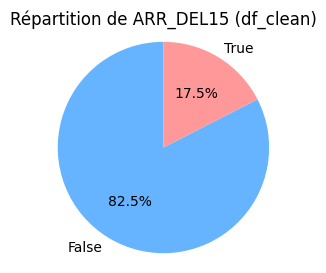

In [42]:
# Visualisation camembert de la répartition de ARR_DEL15 sur df_clean
import matplotlib.pyplot as plt

arr_del15_counts = df_clean['ARR_DEL15'].value_counts(dropna=False)
labels = arr_del15_counts.index.astype(str)
plt.figure(figsize=(3, 3))
plt.pie(arr_del15_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'])
plt.title('Répartition de ARR_DEL15 (df_clean)')
plt.axis('equal')
plt.show()

### Analyse des valeurs manquantes et des outliers


### On construit un sample dataset de 100 000 lignes pour faire les tests de nettoyage et d'analyse


In [5]:
# Échantillon équilibré 50/50 selon la répartition de ARR_DEL15
n = 50000  # nombre d'échantillons par classe pour 100000 au total
df_0 = df_clean[df_clean['ARR_DEL15'] == 0].sample(n=n, random_state=42)
df_1 = df_clean[df_clean['ARR_DEL15'] == 1].sample(n=n, random_state=42)
df_sample = pd.concat([df_0, df_1]).sample(frac=1, random_state=42)  # mélange

# Vérification de la proportion
print(df_sample['ARR_DEL15'].value_counts(normalize=True))
print(df_sample.shape)
df_sample.head()

ARR_DEL15
1    0.5
0    0.5
Name: proportion, dtype: Float64
(100000, 15)


,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
2038943,3,2016-05-25,WN,19393,MDW,DAL,1815,2159,224.0,1,15.0,2214,2035,1,140.0
3392350,3,2016-08-03,B6,20409,LAS,LGB,1625,1830,125.0,1,12.0,1842,1731,1,66.0
2185223,1,2016-05-02,UA,19977,ORD,TPA,1751,1752,1.0,0,24.0,1816,2133,0,162.0
3185148,5,2016-07-08,NK,20416,MSP,BWI,1620,1743,83.0,1,15.0,1758,1945,1,145.0
2530556,7,2016-06-26,WN,19393,LAS,ATL,1840,1904,24.0,1,15.0,1919,130,1,230.0


- on l'enregistre

In [6]:
clean_path4 = "data/processed/sample_cleaned.parquet"
df_sample.to_parquet(clean_path4, index=False)

In [18]:
# ON crée un fichier de sample destiné aux tests : Valeurs non utilisé pour l'entrainnement

# On récupère les index utilisés dans le sample d'entraînement
sample_idx = set(df_sample.index)

# On filtre df_clean pour ne garder que les lignes hors du sample
df_test_candidates = df_clean.loc[~df_clean.index.isin(sample_idx)]

# On prend un échantillon équilibré 50/50 sur ARR_DEL15
n_test = 500  # 500 par classe pour 1000 au total

df_test_0 = df_test_candidates[df_test_candidates['ARR_DEL15'] == 0].sample(n=n_test, random_state=123)
df_test_1 = df_test_candidates[df_test_candidates['ARR_DEL15'] == 1].sample(n=n_test, random_state=123)
df_test = pd.concat([df_test_0, df_test_1]).sample(frac=1, random_state=123)

print(df_test['ARR_DEL15'].value_counts(normalize=True))
print(df_test.shape)
df_test.head()


clean_path5 = "data/processed/sample_cleaned.parquet"
df_test.to_parquet(clean_path5, index=False)
# df_test.to_csv("data/processed/sample_test_1000.csv", index=False)

ARR_DEL15
0    0.5
1    0.5
Name: proportion, dtype: Float64
(1000, 15)


In [49]:
# Répartition des valeurs pour chaque colonne du DataFrame
for col in df_sample.columns:
    print(f"\n--- Répartition pour la colonne : {col} ---")
    print(df_sample[col].value_counts(dropna=False, normalize=True).head(20))
    print(f"Total valeurs uniques : {df_sample[col].nunique(dropna=False)}")


--- Répartition pour la colonne : DAY_OF_WEEK ---
DAY_OF_WEEK
5    0.15048
3    0.14909
1    0.14778
4    0.14725
2    0.14352
7    0.14075
6    0.12113
Name: proportion, dtype: Float64
Total valeurs uniques : 7

--- Répartition pour la colonne : FL_DATE ---
FL_DATE
2016-11-28    0.00346
2016-08-17    0.00335
2016-09-19    0.00330
2016-06-05    0.00328
2016-08-03    0.00327
2016-06-13    0.00326
2016-08-05    0.00326
2016-07-22    0.00326
2016-06-21    0.00324
2016-11-14    0.00324
2016-09-14    0.00324
2016-10-19    0.00323
2016-08-25    0.00322
2016-03-04    0.00322
2016-07-01    0.00321
2016-08-11    0.00320
2016-06-24    0.00320
2016-07-08    0.00320
2016-11-29    0.00319
2016-01-03    0.00319
Name: proportion, dtype: float64
Total valeurs uniques : 366

--- Répartition pour la colonne : UNIQUE_CARRIER ---
UNIQUE_CARRIER
WN    0.23776
DL    0.16909
AA    0.15976
OO    0.11020
UA    0.09633
EV    0.08252
B6    0.04666
AS    0.03025
NK    0.02519
F9    0.01677
HA    0.01374
VX    0.

- => On drop CANCELLED CANCELLATION_CODE et DIVERTED qui n'ont pas de diversité (Mis à jour dans le fichier dataset_descrition)  
- df_sample = df_sample.drop(columns=['CANCELLED', 'CANCELLATION_CODE', 'DIVERTED'], errors='ignore')
- CRS_DEP_TIME
- DEP_TIME
- WHEELS_OFF
- CRS_ARR_TIME
doivent etre converti en int

- SAMPLE_CSV On se fait une petite sortie de controle humaine de 1000 lignes en csv

In [40]:

sample_1000 = df_sample.sample(n=1000, random_state=42)
sample_1000.to_csv("data/processed/sample_1000.csv", index=False)


In [57]:
df_sample.describe().T


,count,mean,min,25%,50%,75%,max,std
DAY_OF_WEEK,100000.0,3.93707,1.0,2.0,4.0,6.0,7.0,1.987705
FL_DATE,100000,2016-07-04 12:31:52.896000,2016-01-01 00:00:00,2016-04-04 00:00:00,2016-07-07 00:00:00,2016-10-03 00:00:00,2016-12-31 00:00:00,NaN
AIRLINE_ID,100000.0,19897.30578,19393.0,19790.0,19805.0,20304.0,21171.0,378.686841
CRS_DEP_TIME,100000.0,1331.39451,2.0,915.0,1325.0,1735.0,2359.0,489.35694
DEP_TIME,100000.0,1335.05475,1.0,918.0,1330.0,1744.0,2400.0,502.211344
DEP_DELAY,100000.0,8.36784,-42.0,-5.0,-2.0,6.0,500.0,34.059327
TAXI_OUT,100000.0,16.14717,1.0,11.0,14.0,19.0,168.0,8.76049
WHEELS_OFF,100000.0,1357.01832,1.0,932.0,1343.0,1759.0,2400.0,503.846178
CRS_ARR_TIME,100000.0,1491.02888,1.0,1105.0,1520.0,1920.0,2400.0,516.515364
CRS_ELAPSED_TIME,100000.0,145.54777,18.0,88.0,126.0,178.0,695.0,76.723204


La valeur max pour DEP_DELAY (1190.0) ne semble pas représentative de la distribution


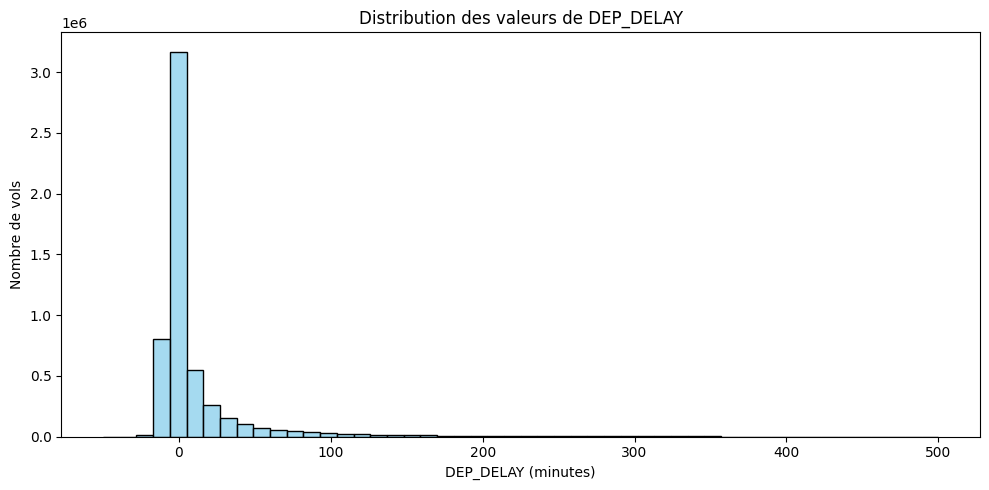

In [58]:
# Histogramme de la colonne DEP_DELAY pour visualiser la distribution des volumes
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['DEP_DELAY'].dropna(), bins=50, kde=False, color='skyblue')
plt.title('Distribution des valeurs de DEP_DELAY')
plt.xlabel('DEP_DELAY (minutes)')
plt.ylabel('Nombre de vols')
plt.tight_layout()
plt.show()

In [30]:
# compte le volume de valeurs dans le groupe 500 3000"
df_clean[df_clean['DEP_DELAY'].between(500, 3000)].shape[0]
# => on traite l'info dans la partie cleaning

3461

In [14]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 390691 to 2197729
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DAY_OF_WEEK       100000 non-null  Int64         
 1   FL_DATE           100000 non-null  datetime64[ns]
 2   UNIQUE_CARRIER    100000 non-null  object        
 3   AIRLINE_ID        100000 non-null  Int64         
 4   ORIGIN            100000 non-null  object        
 5   DEST              100000 non-null  object        
 6   CRS_DEP_TIME      100000 non-null  object        
 7   DEP_TIME          100000 non-null  object        
 8   DEP_DELAY         100000 non-null  float64       
 9   DEP_DEL15         100000 non-null  boolean       
 10  TAXI_OUT          100000 non-null  float64       
 11  WHEELS_OFF        100000 non-null  object        
 12  CRS_ARR_TIME      100000 non-null  object        
 13  ARR_DEL15         100000 non-null  boolean       
 14  CRS

### Visualisation des valeurs manquantes

In [44]:
# Analyse des valeurs manquantes
missing_per_col = df_clean.isna().sum().sort_values(ascending=False)
print("Nombre de valeurs manquantes par colonne :")
display(missing_per_col.to_frame(name="nb_nan"))
print(f"\nNombre total de valeurs manquantes : {missing_per_col.sum()}")

Nombre de valeurs manquantes par colonne :


,nb_nan
DAY_OF_WEEK,0
FL_DATE,0
UNIQUE_CARRIER,0
AIRLINE_ID,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
DEP_DEL15,0



Nombre total de valeurs manquantes : 0


<Axes: >

<Axes: >

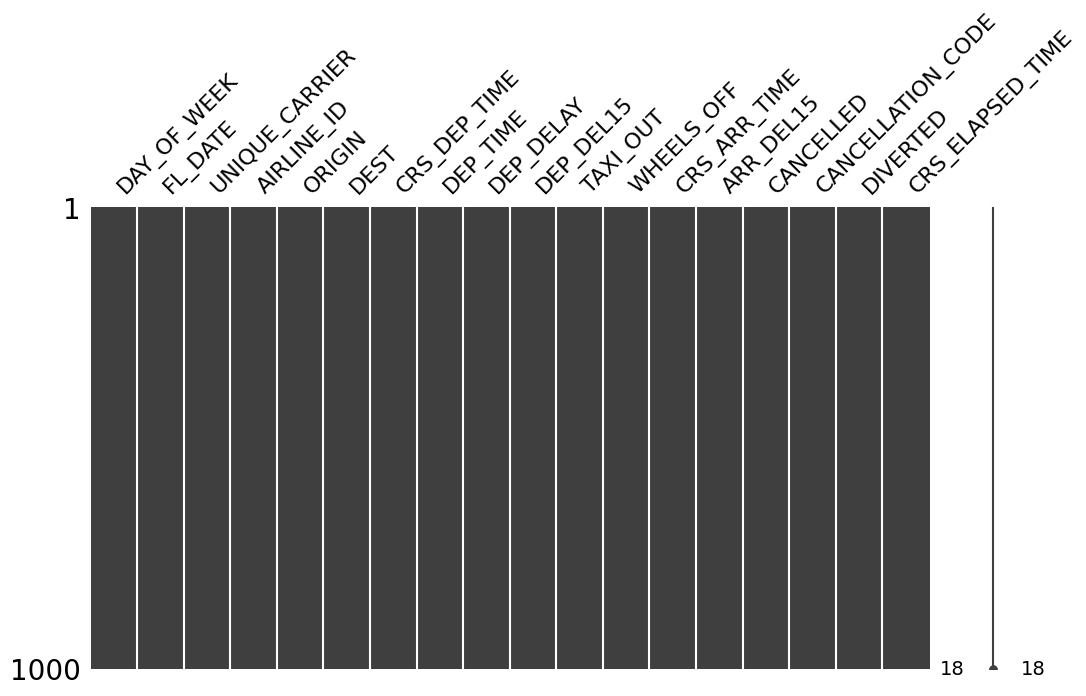

In [43]:
# Visualisation des valeurs manquantes
import missingno as msno
msno.matrix(df_sample.sample(1000), figsize=(12, 6))

In [ ]:
# Analyse des outliers sur les colonnes numériques
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns
# for col in num_cols:
#     plt.figure(figsize=(8, 4))
#     sns.boxplot(x=df_sample[col].dropna(), color='orange')
#     plt.title(f"Boxplot de {col}")
#     plt.show()
    
    
# import matplotlib.pyplot as plt
# import seaborn as sns
# num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
# print(f"Colonnes numériques : {num_cols.tolist()}")
# Visualisation des distributions
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df_sample[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()

# Entrainement de plusieurs modèles

## Régression Logistique  (ARR_DEL15)

In [94]:
# Modélisation : StandardScaler + LogisticRegression sur df_clean (cible ARR_DEL15)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context :
sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle
logreg = LogisticRegression(random_state=42, max_iter=500)
logreg.fit(X_train_scaled, y_train)

# Prédiction des probabilités
pred_prob = logreg.predict_proba(X_test_scaled)

# Score AUC
auc_score = roc_auc_score(y_test, pred_prob[:,1])
print(f"AUC score (LogisticRegression) : {auc_score:.4f}")

# Rapport de classification
y_pred = logreg.predict(X_test_scaled)
print(f"Classification LogisticRegression : \n{classification_report(y_test, y_pred, digits=3)}")


AUC score (LogisticRegression) : 0.9471
Classification LogisticRegression : 
              precision    recall  f1-score   support

           0      0.878     0.924     0.900      1514
           1      0.918     0.869     0.893      1486

    accuracy                          0.897      3000
   macro avg      0.898     0.896     0.897      3000
weighted avg      0.898     0.897     0.897      3000



## DecisionTreeClassifier
- 1er jet 0.8619
- J'ai revu les répartition et améliorer les données d'horaire pour analyse => 0.8615 ! C'est pire :(

In [93]:

# Modélisation : StandardScaler + DecisionTreeClassifier sur df_clean (cible ARR_DEL15)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

sample_train = df_sample.copy()

# on converti le datetime en timstamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context : 
sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)  # sklearn attend des int pour la cible
X = sample_train.drop(columns=['ARR_DEL15'])


# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

# Prédiction des probabilités
pred_prob = clf.predict_proba(X_test_scaled)

# Score AUC
auc_score = roc_auc_score(y_test, pred_prob[:,1])
print(f"AUC score : {auc_score:.4f}")


y_pred_dt = clf.predict(X_test_scaled)

print(f"Classification DecisionTreeClassifier : \n{classification_report(y_test, y_pred_dt, digits=3)}")


AUC score : 0.8530
Classification DecisionTreeClassifier : 
              precision    recall  f1-score   support

           0      0.855     0.854     0.854      1514
           1      0.851     0.852     0.852      1486

    accuracy                          0.853      3000
   macro avg      0.853     0.853     0.853      3000
weighted avg      0.853     0.853     0.853      3000



## RandomForestClassifier
- 0.9562 sur 100k lignes temps d'apprentissage : 2 min 30
- AUC moyen : 0.9609

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cross-validation (nouvel objet)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=100), X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC scores (cross-validation) : {cv_scores}")
print(f"AUC moyen : {np.mean(cv_scores):.4f}")

# Entraînement du modèle RandomForest sur le train set
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train_scaled, y_train)

# Rapport de classification pour RandomForestClassifier
y_pred_rf = rf_clf.predict(X_test_scaled)
print(f"Classification RandomForestClassifier : \n{classification_report(y_test, y_pred_rf, digits=3)}")





AUC scores (cross-validation) : [0.96176436 0.96181509 0.96212316 0.95944771 0.95921592]
AUC moyen : 0.9609
Classification RandomForestClassifier : 
              precision    recall  f1-score   support

           0      0.881     0.933     0.906     14906
           1      0.930     0.876     0.902     15094

    accuracy                          0.904     30000
   macro avg      0.905     0.904     0.904     30000
weighted avg      0.906     0.904     0.904     30000



# Gradiant Boosting
## lightgbm AUC score (LightGBM) : 0.9643




In [97]:

# Modélisation : LightGBMClassifier sur df_clean (cible ARR_DEL15)
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.metrics import classification_report

sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context : 
sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle LightGBM
lgb_clf = lgb.LGBMClassifier(random_state=42, n_estimators=100)
lgb_clf.fit(X_train_scaled, y_train)

# Prédiction des classes
y_pred = lgb_clf.predict(X_test_scaled)


# Prédiction des probabilités
lgb_pred_prob = lgb_clf.predict_proba(X_test_scaled)

# Score AUC
lgb_auc_score = roc_auc_score(y_test, lgb_pred_prob[:,1])
print(f"AUC score (LightGBM) : {lgb_auc_score:.4f}")


# Rapport de classification
print(f"Classification LightGBM : \n{classification_report(y_test, y_pred, digits=3)}")

[LightGBM] [Info] Number of positive: 3542, number of negative: 3458
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2280
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 146
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506000 -> initscore=0.024001
[LightGBM] [Info] Start training from score 0.024001
AUC score (LightGBM) : 0.9567
Classification LightGBM : 
              precision    recall  f1-score   support

           0      0.877     0.931     0.903      1514
           1      0.925     0.867     0.895      1486

    accuracy                          0.899      3000
   macro avg      0.901     0.899     0.899      3000
weighted avg      0.901     0.899     0.899      3000

AUC score (LightGBM) : 0.9567
Classification LightGBM : 
              precision    recall  f1-score   support

           0  

e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# => Le model choisi est le LightGBMClassifier 
- car il est rapide et suffisement précis meme si random forest est plus précis mais trop long à entrainer